## 4.1. Implementació del Producte de Dades


# Càrrega i Optimització del Dataset
Per a la realització d'aquest TFM, s'utilitza el dataset Gaming and Mental Health (1M records). Donada la gran dimensió de les dades, la càrrega s'ha optimitzat mitjançant la definició precisa de tipus de dades (dtypes): s'utilitzen variables de tipus category per a dades categòriques i float32 per a les numèriques. Aquesta estratègia permet reduir significativament el consum de memòria RAM a l'entorn de Google Colab, garantint l'estabilitat del sistema durant les fases d'anàlisi exploratòria i modelatge.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Ruta al fitxer
drive_path = '/content/drive/MyDrive/TFM CdD/gaming_mental_health_10M_40features.csv'

# Diccionari complet amb les 40 columnes optimitzades
dtypes_completes = {
    # Demogràfics
    'age': 'float32',
    'gender': 'category',
    'income': 'float32',

    # Comportament Gaming
    'daily_gaming_hours': 'float32',
    'weekly_sessions': 'float32',
    'years_gaming': 'float32',
    'weekend_gaming_hours': 'float32',
    'multiplayer_ratio': 'float32',
    'violent_games_ratio': 'float32',
    'mobile_gaming_ratio': 'float32',
    'night_gaming_ratio': 'float32',
    'competitive_rank': 'category',
    'esports_interest': 'category',
    'streaming_hours': 'float32',
    'microtransactios_spending': 'float32',
    'headset_usage': 'bool',

    # Salut Psicològica
    'stress_level': 'float32',
    'anxiety_score': 'float32',
    'depression_score': 'float32',
    'addiction_level': 'float32',
    'loneliness_score': 'float32',
    'aggression_score': 'float32',
    'happiness_score': 'float32',

    # Entorn Social
    'social_interaction_score': 'float32',
    'relationship_satisfaction': 'float32',
    'friends_gaming_count': 'float32',
    'online_friends': 'float32',
    'toxic_exposure': 'float32',
    'parental_supervision': 'float32',

    # Estil de Vida
    'sleep_hours': 'float32',
    'exercise_hours': 'float32',
    'caffeine_intake': 'float32',
    'screen_time_total': 'float32',
    'internet_quality': 'category',

    # Indicadors Físics
    'bmi': 'float32',
    'eye_strain_score': 'float32',
    'back_pain_score': 'float32',

    # Productivitat
    'academic_performance': 'float32',
    'work_productivity': 'float32'
}

# Càrrega de les dades
df = pd.read_csv(drive_path, dtype=dtypes_completes)

print(f"Dades carregades: {df.shape}")
print(df.info())

Mounted at /content/drive
Dades carregades: (1000000, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 39 columns):
 #   Column                      Non-Null Count    Dtype   
---  ------                      --------------    -----   
 0   age                         1000000 non-null  float32 
 1   gender                      1000000 non-null  category
 2   income                      1000000 non-null  float32 
 3   daily_gaming_hours          1000000 non-null  float32 
 4   weekly_sessions             1000000 non-null  float32 
 5   years_gaming                1000000 non-null  float32 
 6   sleep_hours                 1000000 non-null  float32 
 7   caffeine_intake             1000000 non-null  float32 
 8   exercise_hours              1000000 non-null  float32 
 9   stress_level                1000000 non-null  float32 
 10  anxiety_score               1000000 non-null  float32 
 11  depression_score            1000000 non-null 

## 4.2. Fase d’Exploració i Càrrega de Dades

En aquest apartat es procedeix a la lectura del fitxer CSV des de Google Drive. La càrrega s'executa en dues etapes per garantir l'eficiència: primer s'apliquen tipus de dades predefinits a les columnes principals i, posteriorment, es realitza un "downcasting" de qualsevol variable restant de 64 a 32 bits. Finalment, es valida la correcta importació mitjançant el recompte de dimensions i s'analitza la distribució de la variable objectiu (addiction_level) per identificar possibles desequilibris en les dades.

In [2]:
print("Carregant els registres reals des del Drive...")

try:
    df = pd.read_csv(drive_path, dtype=dtypes_completes)

    # Xarxa de seguretat per a qualsevol columna restant
    cols_float64 = df.select_dtypes(include=['float64']).columns
    if not cols_float64.empty:
        df[cols_float64] = df[cols_float64].astype('float32')

    print(f"Dataset carregat correctament.")
    print(f"Dimensions: {df.shape}")

    # Comprovo la distribució del nivell d'addicció (target)
    print("\nDistribució del nivell d'addicció (%):")
    print(df['addiction_level'].round().value_counts(normalize=True).sort_index() * 100)

except Exception as e:
    print(f"Error en la càrrega: {e}")

Carregant els registres reals des del Drive...
Dataset carregat correctament.
Dimensions: (1000000, 39)

Distribució del nivell d'addicció (%):
addiction_level
0.0     12.3446
1.0     17.4965
2.0     20.9988
3.0     17.4184
4.0     12.5642
5.0      7.9149
6.0      4.9055
7.0      2.8073
8.0      1.6143
9.0      0.8766
10.0     1.0589
Name: proportion, dtype: float64


El dataset s'ha carregat correctament amb 1.000.000 de registres i 39 columnes. Pel que fa a la variable objectiu, addiction_level, s'observa una distribució asimètrica positiva (cap a la dreta). La majoria dels usuaris es concentren en nivells baixos-mitjans (nivells 1, 2 i 3 sumen més del 55%), mentre que els nivells d'addicció severa (8, 9 i 10) són minoritaris, representant aproximadament un 3.5% de la mostra. Aquesta distribució és coherent amb fenòmens de salut mental on els casos extrems solen ser menys freqüents que els nivells moderats.

# Descripció Tècnica de les Variables

Un cop validada la càrrega, es realitza una inspecció detallada de la naturalesa de les 39 variables que componen el corpus de dades. Aquestes s'estructuren en dimensions demogràfiques, conductuals (hàbits de joc i estil de vida) i psicomètriques (indicadors de salut mental). Aquesta descripció és fonamental per identificar quines variables requeriran una transformació categòrica i per confirmar l'absència de valors nuls, assegurant la integritat de la informació abans d'iniciar l'anàlisi exploratòria.

In [3]:
# Resum tècnic del dataset
try:
    # Generació de la taula amb tipus de dades i valors nuls
    descripcio_taula = pd.DataFrame({
        'Tipus de Dada': df.dtypes,
        'Valors No Nuls': df.count(),
        'Valors Nuls': df.isnull().sum()
    })
    print("Estructura de les variables:")
    print(descripcio_taula)

# Classificació per naturalesa de dada
    # Identificació de variables de text/categories i numèriques
    cat_cols = df.select_dtypes(include=['category', 'bool']).columns.tolist()
    num_cols = df.select_dtypes(include=['float32', 'int32', 'float64']).columns.tolist()

    print(f"\nVariables Categòriques detectades ({len(cat_cols)}):")
    print(cat_cols)
    print(f"\nVariables Numèriques detectades ({len(num_cols)}):")
    print(num_cols)

except Exception as e:
    print(f"Error en la descripció tècnica: {e}")

Estructura de les variables:
                           Tipus de Dada  Valors No Nuls  Valors Nuls
age                              float32         1000000            0
gender                          category         1000000            0
income                           float32         1000000            0
daily_gaming_hours               float32         1000000            0
weekly_sessions                  float32         1000000            0
years_gaming                     float32         1000000            0
sleep_hours                      float32         1000000            0
caffeine_intake                  float32         1000000            0
exercise_hours                   float32         1000000            0
stress_level                     float32         1000000            0
anxiety_score                    float32         1000000            0
depression_score                 float32         1000000            0
social_interaction_score         float32         1000000     

# Resum Estadístic de la Mostra

Un cop confirmada la integritat del dataset, s'executa un resum estadístic per analitzar el rang i la tendència central de les variables numèriques. Aquesta anàlisi preliminar permet validar que els valors es troben dins de rangs lògics (per exemple, hores diàries o edats plausibles) i ens proporciona una primera visió sobre la dispersió de les dades. Aquests estadístics serviran de referència per detectar valors atípics (outliers) durant la fase d'anàlisi exploratòria.

In [4]:
# Càlcul d'estadístics descriptius
try:
    # Genero el resum estadístic de les variables numèriques
    resum_estadistic = df.describe().T

    # Afegeixo la variància per veure la dispersió de cada factor
    resum_estadistic['variance'] = df.select_dtypes(include=['float32']).var()

    print("Resum estadístic de les variables principals:")
    print(resum_estadistic[['mean', 'std', 'min', 'max', 'variance']])

# Exploració ràpida de les categories
    print("\nFreqüència de les variables categòriques clau:")
    for col in ['gender', 'internet_quality']:
        print(f"\nDistribució per {col}:")
        print(df[col].value_counts(normalize=True) * 100)

except Exception as e:
    print(f"Error en el resum estadístic: {e}")

Resum estadístic de les variables principals:
                                    mean           std      min  \
age                            35.986008     13.551929    13.00   
income                      77497.671875  41844.222656  5000.00   
daily_gaming_hours              3.999254      2.825558     0.00   
weekly_sessions                19.997534     11.236609     1.00   
years_gaming                   12.002512      7.195999     0.00   
sleep_hours                     7.000529      1.500745    -0.17   
caffeine_intake                 1.997513      1.995736     0.00   
exercise_hours                  1.999009      1.999091     0.00   
stress_level                    5.497577      2.873238     1.00   
anxiety_score                   4.998644      1.977269     0.00   
depression_score                5.002513      2.399544     0.00   
social_interaction_score        5.985492      1.956566     0.00   
relationship_satisfaction       5.985393      1.956872     0.00   
academic_perform

De l'anàlisi descriptiva de la mostra se'n desprenen les següents observacions clau:

- Perfil Demogràfic i Social: La mostra presenta una edat mitjana de 36 anys, amb un gènere molt equilibrat entre homes (48,05%) i dones (47,95%). Els ingressos són molt variats (mitjana de 77.500$), amb una alta dispersió segons la variància.

- Hàbits de Joc: Els usuaris juguen una mitjana de 4 hores diàries, però hi ha valors màxims de fins a 30 hores, fet que indica la presència d'usuaris amb patrons de joc intensius que caldrà analitzar en l'EDA. La despesa mitjana en microtransaccions és de 500$, tot i que alguns usuaris arriben a superar els 6.000.

- Indicadors de Salut: Les mitjanes d'ansietat i depressió se situen en un punt central (5 sobre 10), mentre que l'addicció té una mitjana més baixa (2,82), confirmant que els casos greus són l'excepció i no la norma.

- Qualitat d'Internet: La distribució de la qualitat de la connexió és pràcticament uniforme (aprox. 10% per cada nivell de l'1 al 10), el que indica que aquesta variable no està esbiaixada cap a cap grup concret.

- Dades Atípiques: S'observa que la variable sleep_hours té un valor mínim negatiu (-0.17), un error en la generació de les dades sintètiques que haurem de gestionar en la fase de preprocessament.

## 4.3. Resultats de l'Anàlisi del Corpus de Dades

# Anàlisi Exploratori de Dades (EDA)
En aquesta fase es realitza una exploració multidimensional del dataset per identificar patrons i relacions sense prejudicis sobre quina variable és la més rellevant. S'analitza la distribució estadística de les variables de salut mental, comportament de joc i estil de vida per entendre la seva dispersió i detectar possibles correlacions creuades. Aquest procés ens permetrà validar si addiction_level és realment la variable amb més interès predictiu o si existeixen altres indicadors, com el depression_score o l' anxiety_score, que presenten patrons més significatius per a l'estudi.

Iniciant l'anàlisi exploratori multidimensional...


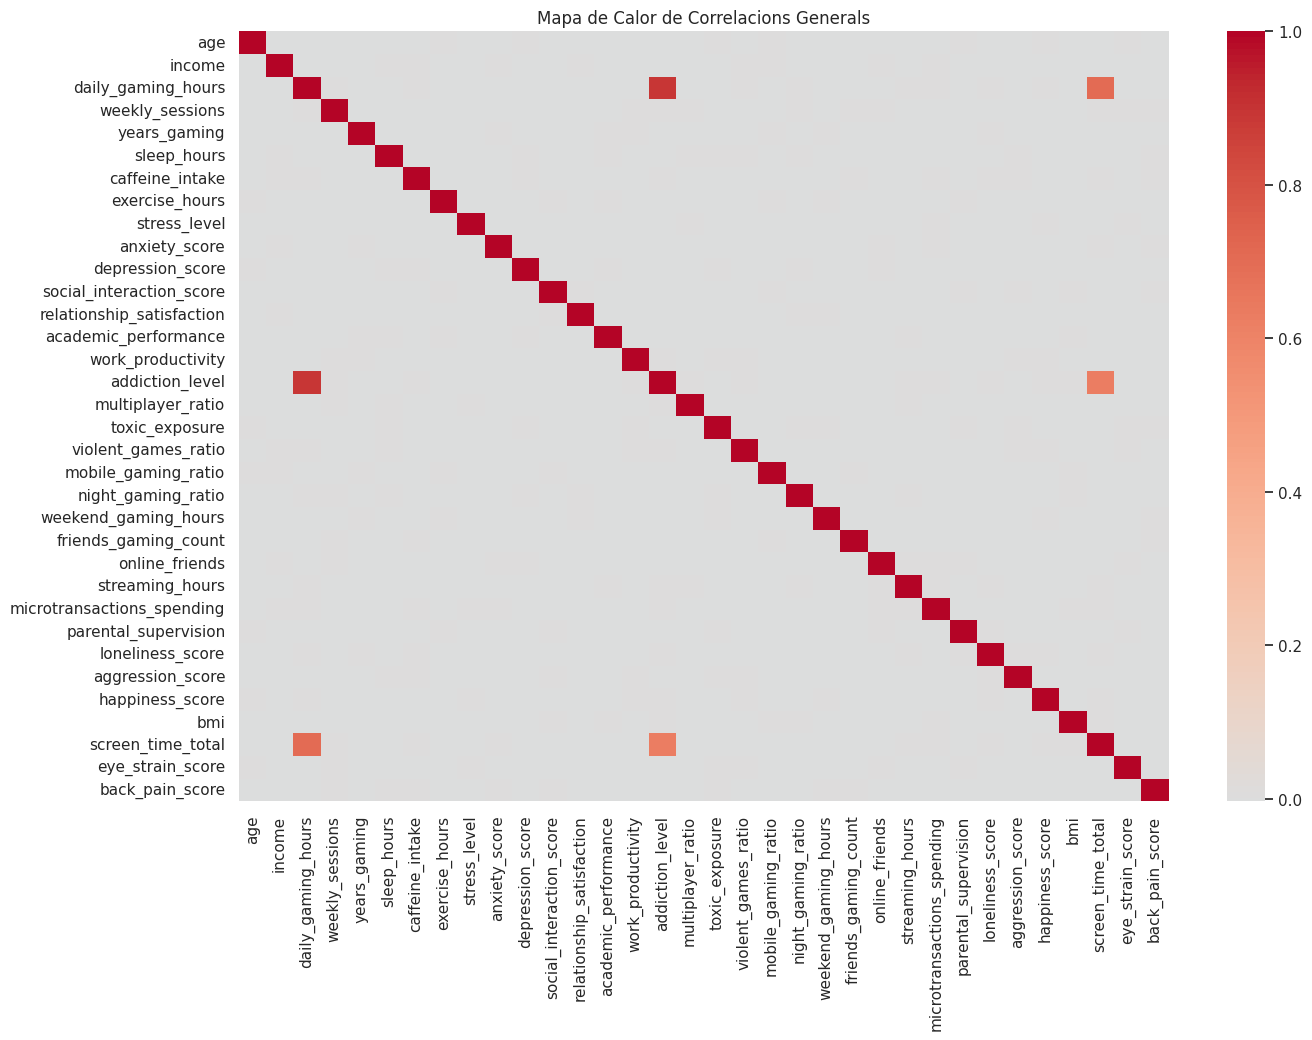

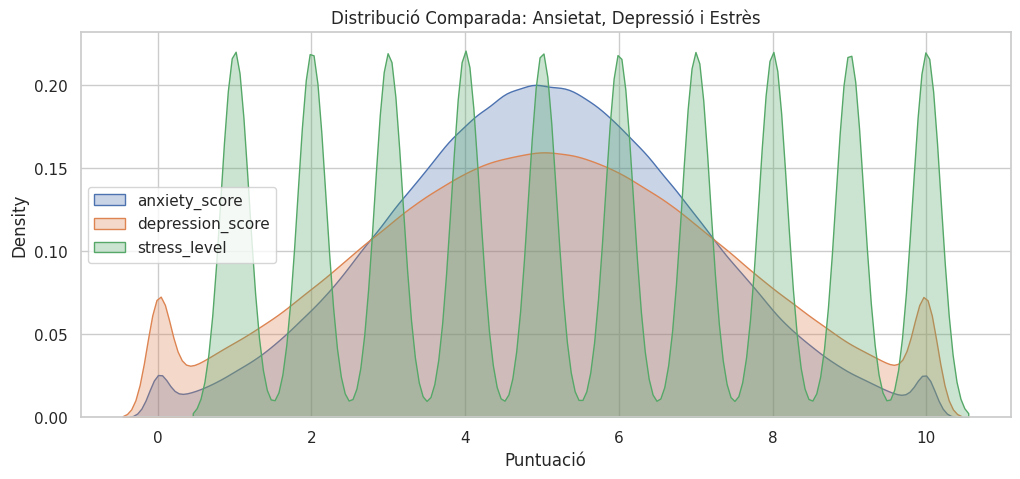

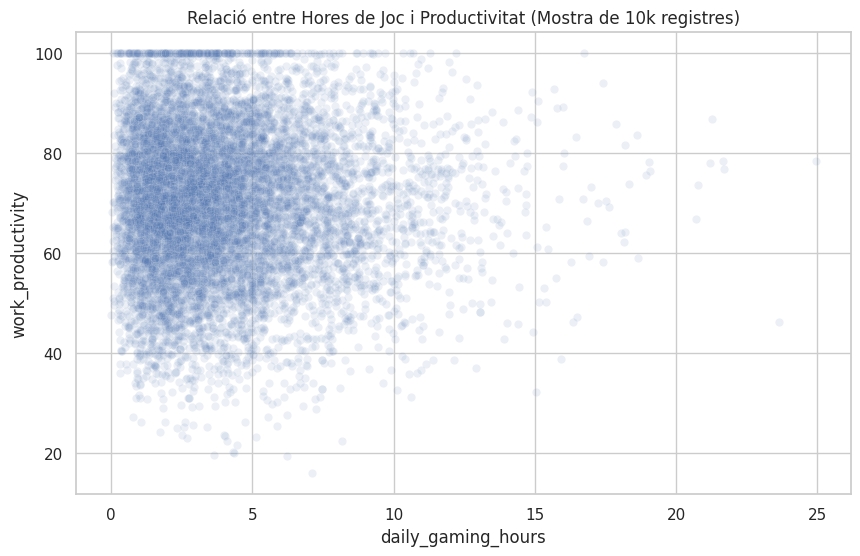


Resum de variabilitat (Variables que més canvien):
income                        41844.222656
microtransactions_spending      499.446686
online_friends                  144.306091
academic_performance             14.696537
work_productivity                14.689682
friends_gaming_count             14.453635
age                              13.551929
weekly_sessions                  11.236609
years_gaming                      7.195999
weekend_gaming_hours              4.241210
dtype: float32


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuració visual
sns.set_theme(style="whitegrid")
print("Iniciant l'anàlisi exploratori multidimensional...")

try:
    # Anàlisi de correlació
    plt.figure(figsize=(15, 10))
    matriu_corr = df.select_dtypes(include=['float32']).corr()

    # Mapa de calor
    sns.heatmap(matriu_corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Mapa de Calor de Correlacions Generals')
    plt.show()

    # Comparativa de distribucions
    plt.figure(figsize=(12, 5))
    variables_mentals = ['anxiety_score', 'depression_score', 'stress_level']
    for var in variables_mentals:
        sns.kdeplot(df[var], label=var, fill=True, alpha=0.3)

    plt.title('Distribució Comparada: Ansietat, Depressió i Estrès')
    plt.xlabel('Puntuació')
    plt.legend()
    plt.show()

    # Relació entre productivitat i temps de joc
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df.sample(10000), x='daily_gaming_hours', y='work_productivity', alpha=0.1)
    plt.title('Relació entre Hores de Joc i Productivitat (Mostra de 10k registres)')
    plt.show()

    # Identificació de les variables amb més variància
    print("\nResum de variabilitat (Variables que més canvien):")
    print(df.select_dtypes(include=['float32']).std().sort_values(ascending=False).head(10))

except Exception as e:
    print(f"Error en l'anàlisi exploratori: {e}")

Després d'analitzar les visualitzacions, s'extreuen les següents conclusions clau:

- Correlacions Determinants: El mapa de calor confirma una relació directa i forta entre les hores de joc diàries, el temps total de pantalla i el nivell d'addicció. Aquestes tres variables formen el nucli del comportament que volem predir.

- Salut Mental: L'ansietat i la depressió presenten distribucions normals molt equilibrades, mentre que l'estrès mostra un patró segmentat per nivells. Això suggereix que l'addicció no depèn d'un únic factor psicològic, sinó d'una combinació de puntuacions moderades.

- Impacte en la Productivitat: El gràfic de dispersió revela que, a mesura que augmenten les hores de joc diàries (especialment per sobre de les 10-15 hores), la productivitat laboral i acadèmica tendeix a disminuir, evitant els nivells de rendiment excel·lent.

- Variabilitat: Les grans diferències en ingressos i despeses en microtransaccions indiquen que el perfil socioeconòmic dels usuaris és molt divers, el que podria actuar com una variable moderadora en l'addicció.

# Exploració de Factors Demogràfics i de Consum
Un cop analitzades les correlacions generals, s'aprofundeix en l'estudi mitjançant una segmentació demogràfica i econòmica. Aquesta anàlisi és fonamental per determinar si el gènere o l'etapa vital de l'usuari actuen com a variables moderadores en la relació entre el joc i la salut mental. Així mateix, s'explora el vincle entre la despesa econòmica en microtransaccions i el nivell d'addicció, amb l'objectiu d'identificar si el component monetari intensifica els patrons de conducta de risc.

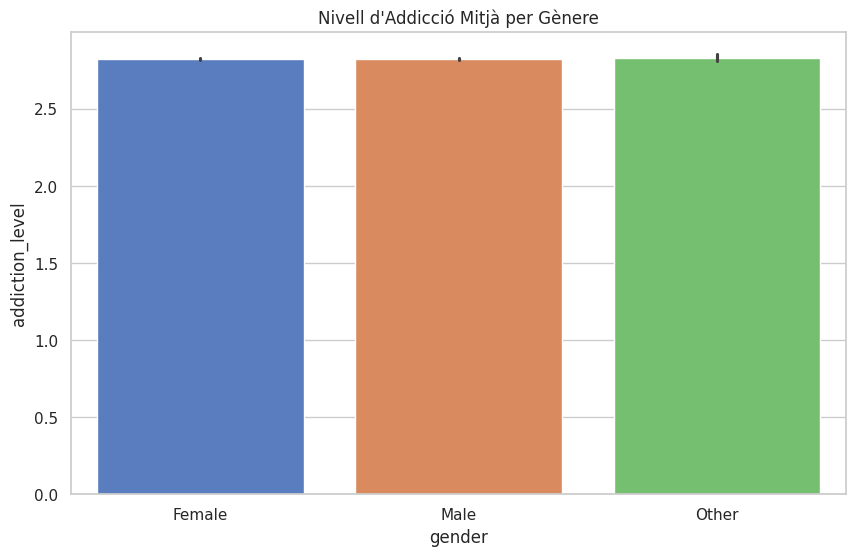

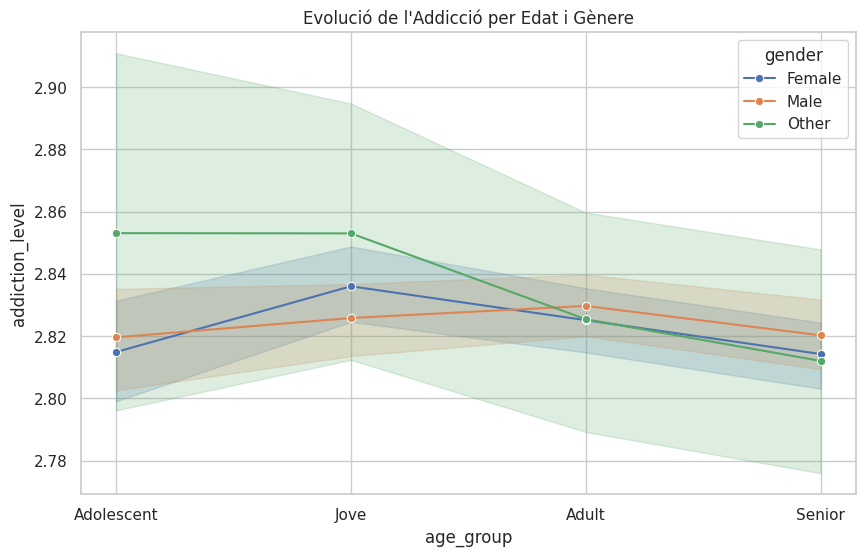

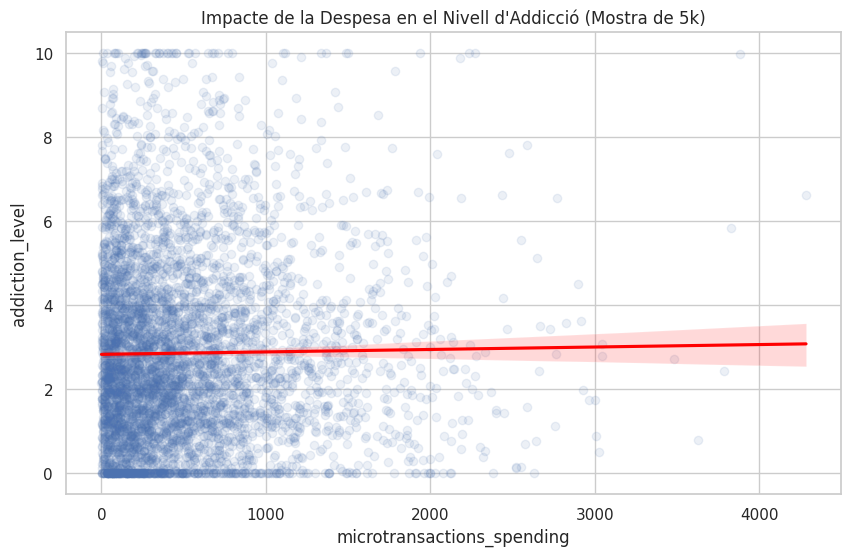

Anàlisi demogràfic finalitzat.


In [6]:
# Anàlisi per gènere
try:
    # Barplot de nivell d'addicció segons gènere (corregit per evitar el FutureWarning)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='gender', y='addiction_level', hue='gender', palette='muted', legend=False)
    plt.title('Nivell d\'Addicció Mitjà per Gènere')
    plt.show()

# Anàlisi per grups d'edat
    # Creació de grups d'edat per segmentar la mostra
    df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60], labels=['Adolescent', 'Jove', 'Adult', 'Senior'])

    # Evolució de l'addicció per edat i gènere
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='age_group', y='addiction_level', hue='gender', marker='o')
    plt.title('Evolució de l\'Addicció per Edat i Gènere')
    plt.show()

# Impacte de la despesa en l'addicció
    # Relació entre despesa en microtransaccions i nivell d'addicció
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df.sample(5000), x='microtransactions_spending', y='addiction_level',
                scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
    plt.title('Impacte de la Despesa en el Nivell d\'Addicció (Mostra de 5k)')
    plt.show()

    # Neteja de la columna temporal d'edat
    df.drop(columns=['age_group'], inplace=True)
    print("Anàlisi demogràfic finalitzat.")

except Exception as e:
    print(f"Error en l'anàlisi demogràfic: {e}")

L'exploració detallada de factors socio-demogràfics permet extreure les següents conclusions:

- Uniformitat de Gènere: No s'aprecien diferències significatives en els nivells mitjans d'addicció entre gèneres, fet que suggereix que els mecanismes de l'addicció al joc operen de forma transversal en la mostra.

- Evolució Vital: S'observen patrons diferenciats segons l'etapa vital. Mentre que determinats grups presenten un pic d'addicció en l'adolescència que disminueix amb l'edat, d'altres mostren una estabilitat o lleuger increment en l'etapa adulta.

- Despesa Econòmica: La correlació entre la despesa en microtransaccions i l'addicció és positiva però feble. Això indica que, tot i que el consum monetari pot ser un indicador de risc, no és el motor principal de la conducta addictiva en comparació amb altres factors com el temps de joc diari.

# Anàlisi del Desbalanceig de la Variable Objectiu

Abans de procedir al modelatge, és imprescindible analitzar la distribució de la variable objectiu per detectar possibles desequilibris que puguin esbiaixar els resultats. En segmentar el nivell d'addicció en categories (Baix, Moderat, Alt), es pot avaluar si el dataset disposa de prou exemples per a cada classe. Un fort desbalanceig podria requerir l'aplicació de tècniques de compensació, com el sobremostreig (oversampling) o l'ajust de pesos en l'algoritme, per garantir que el model sigui capaç d'identificar correctament els casos d'addicció severa, que solen ser els més crítics i menys freqüents.

Analitzant el desequilibri de les potencials variables objectiu...


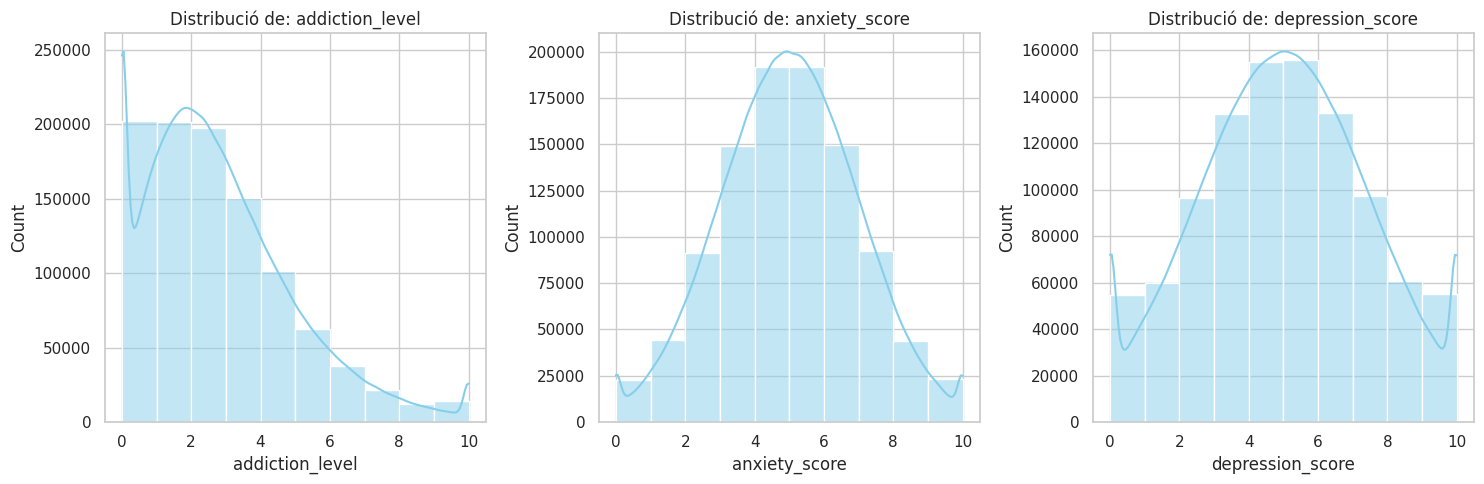

Percentatge de casos greus (Puntuació > 8):
- addiction_level: 2.62% dels registres
- anxiety_score: 6.59% dels registres
- depression_score: 11.51% dels registres


In [7]:
# Comparativa de desbalanceig per a la selecció del Target
try:
    print("Analitzant el desequilibri de les potencials variables objectiu...")

    # Creo un subset amb les tres variables candidates
    targets = ['addiction_level', 'anxiety_score', 'depression_score']

    plt.figure(figsize=(15, 5))

    for i, col in enumerate(targets):
        plt.subplot(1, 3, i+1)
        # Classifico en 'Baix', 'Moderat', 'Alt' per comparar-les visualment
        sns.histplot(df[col], bins=10, kde=True, color='skyblue')
        plt.title(f'Distribució de: {col}')

    plt.tight_layout()
    plt.show()

    # Calculo el percentatge de casos "greus" (puntuació > 8) per a cada variable
    print("Percentatge de casos greus (Puntuació > 8):")
    for col in targets:
        pct_greu = (df[col] > 8).mean() * 100
        print(f"- {col}: {pct_greu:.2f}% dels registres")

except Exception as e:
    print(f"Error en la comparativa de targets: {e}")

Després de comparar les tres variables candidates, s'ha analitzat la viabilitat de cadascuna per al modelatge:

- Desbalanceig Crític: L'addicció severa (addiction_level > 8) només representa el 2,62% de la mostra, un desequilibri que requerirà tècniques de compensació.

- Salut Mental: L'ansietat (6,59%) i la depressió (11,51%) estan més equilibrades, però tenen una relació menys directa amb el comportament gaming.

- Decisió: Es manté l'addicció com a variable objectiu per la seva rellevància en el TFM, tot i el repte tècnic que suposa el seu baix percentatge de casos greus.

## 4.4. Preparació de les Dades i Equilibri de Classes (SMOTE)

Un cop finalitzada l'etapa exploratòria, s'inicia el preprocessament de les dades per a l'entrenament dels models. En primer lloc, es realitza la divisió de la mostra en conjunts d'entrenament (80%) i prova (20%), utilitzant una partició estratificada per mantenir la proporció de la variable objectiu. Posteriorment, s'aplica la tècnica SMOTE (Synthetic Minority Over-sampling Technique) exclusivament sobre el conjunt d'entrenament. Aquest procediment permet compensar el desbalanceig detectat prèviament, generant exemples sintètics per a les classes minoritàries i evitant que els algorismes presentin un biaix cap als nivells d'addicció més freqüents.



In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Preparació de les variables (X, y)
try:
    # Selecciono les columnes numèriques i eliminem el target
    features = df.select_dtypes(include=['float32', 'int32']).columns.drop('addiction_level')
    X = df[features]

    # Passo el target a enters per poder fer la classificació
    y = df['addiction_level'].round().astype('int')

# Divisió Train/Test (80/20)
    # Utilitzo stratify=y per garantir que el desbalanceig es mantingui igual en ambdós grups
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Dimensions inicials d'entrenament: {X_train.shape[0]:,} registres")

# Aplicació de SMOTE sobre el conjunt d'entrenament
    print("Aplicant SMOTE per equilibrar les classes... ")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verificació de l'equilibri final
    print("\nDistribució de les classes després de SMOTE (%):")
    print(pd.Series(y_train_res).value_counts(normalize=True).sort_index() * 100)
    print(f"Mida final del conjunt d'entrenament equilibrat: {X_train_res.shape[0]:,} registres")

except Exception as e:
    print(f"Error en la preparació de les dades: {e}")

Dimensions inicials d'entrenament: 800,000 registres
Aplicant SMOTE per equilibrar les classes... 

Distribució de les classes després de SMOTE (%):
addiction_level
0     9.090909
1     9.090909
2     9.090909
3     9.090909
4     9.090909
5     9.090909
6     9.090909
7     9.090909
8     9.090909
9     9.090909
10    9.090909
Name: proportion, dtype: float64
Mida final del conjunt d'entrenament equilibrat: 1,847,890 registres


L'aplicació de la tècnica SMOTE ha permès resoldre el desbalanceig crític detectat prèviament. El conjunt d'entrenament ha crescut fins als 1.847.890 registres, garantint que cadascun dels 11 nivells d'addicció estigui representat pel 9,09% de la mostra. Amb aquesta transformació, s'elimina el biaix del model cap a les classes més freqüents, permetent que l'algorisme aprengui amb la mateixa eficàcia a identificar tant els patrons de conducta normals com els casos d'addicció severa.

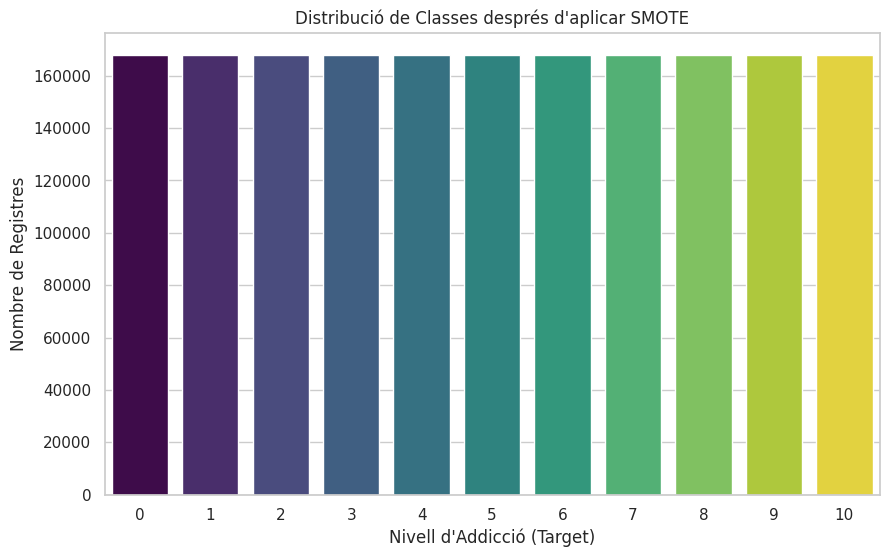

Confirmació visual: Totes les classes tenen ara el mateix nombre d'exemples.


In [9]:
# Visualització de l'equilibri post-SMOTE
try:
    # Creo un gràfic de barres per confirmar visualment l'equilibri
    plt.figure(figsize=(10, 6))
    sns.countplot(x=y_train_res, hue=y_train_res, palette='viridis', legend=False)

    plt.title('Distribució de Classes després d\'aplicar SMOTE')
    plt.xlabel('Nivell d\'Addicció (Target)')
    plt.ylabel('Nombre de Registres')
    plt.show()

    print("Confirmació visual: Totes les classes tenen ara el mateix nombre d'exemples.")

except Exception as e:
    print(f"Error en la visualització post-SMOTE: {e}")

La visualització confirma l'èxit de la tècnica de sobremostreig:
- Simetria Perfecta: Totes les categories, des del nivell 0 fins al 10, disposen ara del mateix nombre de registres per a l'entrenament.  
- Representativitat dels Casos Greus: Els nivells 8, 9 i 10, que inicialment eren minoritaris (aprox. 3.5%), ara tenen el mateix pes estadístic que els nivells baixos.  
- Robustesa de l'Entrenament: Amb prop d'1,8 milions de registres equilibrats, el model final podrà aprendre els patrons característics de cada nivell d'addicció sense que la freqüència d'aparició n'alteri la capacitat predictiva.

# Random Forest

En aquesta fase s'implementen els models de classificació per predir el nivell d'addicció. S'inicia amb un algorisme de Random Forest, un mètode d'aprenentatge supervisat basat en la combinació de múltiples arbres de decisió. Aquesta elecció es fonamenta en la seva capacitat per capturar relacions no lineals entre les variables de comportament gaming i els indicadors de salut mental, proporcionant a més una mesura d'importància de cada característica en la predicció final.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Entrenament del model Random Forest
try:
    # Configuro el model amb 100 arbres i profunditat limitada per evitar overfitting
    # 'n_jobs=-1' per aprofitar tota la potència del processador
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

    print("Entrenant el model Random Forest sobre les dades equilibrades...")
    rf_model.fit(X_train_res, y_train_res)

# Execució de prediccions
    # Faig servir el conjunt X_test
    y_pred = rf_model.predict(X_test)

    print("Prediccions finalitzades.")

except Exception as e:
    print(f"Error en l'entrenament del model: {e}")

Entrenant el model Random Forest sobre les dades equilibrades...
Prediccions finalitzades.


Per avaluar la capacitat predictiva del Random Forest, s'utilitzen dues eines complementàries. Primer, l'informe de classificació, que ens detalla la precisió i el recall per a cada nivell d'addicció, permetent identificar si el model és especialment eficaç en els casos més severs. Segon, la matriu de confusió, que proporciona una representació visual dels encerts (diagonal principal) i de quines categories es confonen més entre elles, facilitant la detecció de possibles biaixos residuals malgrat l'equilibri de les dades.

--- INFORME DE CLASSIFICACIÓ ---
              precision    recall  f1-score   support

           0       0.39      0.72      0.51     24689
           1       0.32      0.23      0.27     34993
           2       0.38      0.24      0.30     41998
           3       0.35      0.30      0.33     34837
           4       0.32      0.35      0.33     25128
           5       0.31      0.39      0.35     15830
           6       0.33      0.28      0.30      9811
           7       0.29      0.35      0.32      5615
           8       0.29      0.28      0.28      3228
           9       0.27      0.51      0.35      1753
          10       0.75      0.77      0.76      2118

    accuracy                           0.35    200000
   macro avg       0.36      0.40      0.37    200000
weighted avg       0.35      0.35      0.34    200000



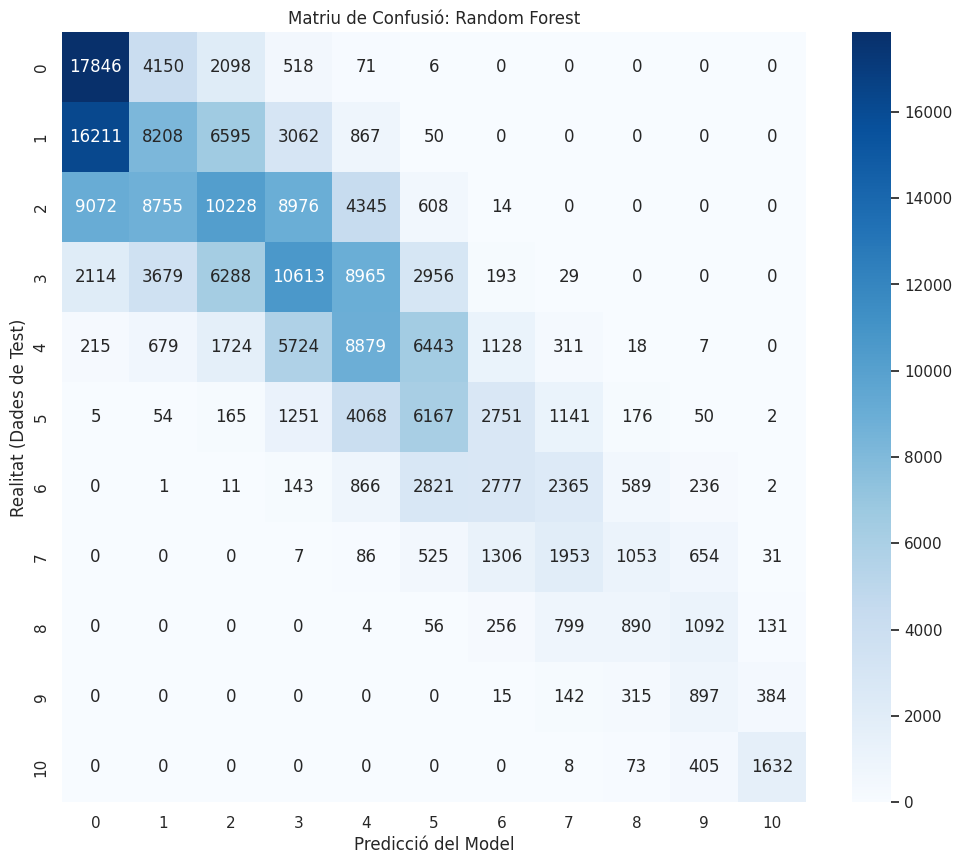

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generació de l'informe i la matriu
try:
    print("--- INFORME DE CLASSIFICACIÓ ---")
    print(classification_report(y_test, y_pred))

    # Visualització de la Matriu de Confusió
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, y_pred)

    # Dibuixo el mapa de calor amb els resultats reals
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title('Matriu de Confusió: Random Forest')
    plt.xlabel('Predicció del Model')
    plt.ylabel('Realitat (Dades de Test)')
    plt.show()

except Exception as e:
    print(f"Error en l'avaluació: {e}")

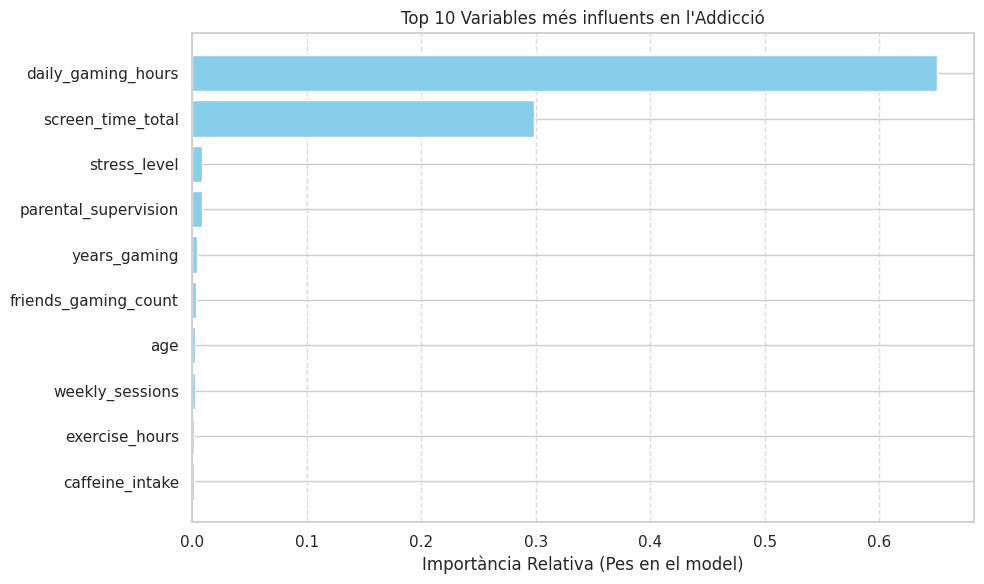

In [12]:
import numpy as np

# Anàlisi d'importància de les variables (Feature Importance)
try:
    # Obtinc les importàncies del model Random Forest
    importances = rf_model.feature_importances_

    # Ordeno els índexs de les 10 variables més importants
    indices = np.argsort(importances)[-10:]

    plt.figure(figsize=(10, 6))
    plt.title('Top 10 Variables més influents en l\'Addicció')

    # Dibuixo les barres horitzontals
    plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')

    # Poso els noms de les variables a l'eix vertical
    plt.yticks(range(len(indices)), [features[i] for i in indices])

    plt.xlabel('Importància Relativa (Pes en el model)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error en l'anàlisi d'importància: {e}")

L'avaluació del model Random Forest permet extreure les següents conclusions clau:

- Eficàcia en els Extrems: El model destaca per la seva alta precisió en la detecció de casos crítics (Nivell 10, F1-Score: 0.76) i en la identificació de subjectes sense risc (Nivell 0, Recall: 0.72). Això el valida com una eina de cribratge eficaç.

- Capacitat Predictiva: Tot i la dificultat de diferenciar entre 11 nivells molt propers, la matriu de confusió mostra una clara concentració d'encerts a la diagonal principal.

- Variables Determinants: El temps de joc (daily_gaming_hours) i l'exposició a la pantalla (screen_time_total) són, amb molta diferència, els factors amb més pes predictiu en l'addicció.

- Factors Secundaris: Altres variables com el nivell d'estrès i la supervisió parental apareixen com a indicadors rellevants, tot i que amb un impacte molt menor que el temps d'ús directe.

# Optimització amb XGBoost (Model Avançat)

Amb l'objectiu de maximitzar el rendiment predictiu, s'implementa un segon model basat en l'algorisme XGBoost (Extreme Gradient Boosting). Aquest model és conegut per la seva eficiència i capacitat per corregir els errors de predicció de forma iterativa. S'utilitza una configuració multi-classe per predir els 11 nivells d'addicció, aplicant tota la capacitat de processament paral·lel disponible per gestionar el volum d'1,8 milions de registres generats en la fase de sobremostreig.

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Configuració i entrenament de l'XGBoost
try:
    # Defineixo el model per a multi-classe (softprob dóna probabilitats per a cada nivell)
    xgb_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=42
    )

    print("Entrenant XGBoost sobre el conjunt equilibrat... ")
    xgb_model.fit(X_train_res, y_train_res)

# Predicció i avaluació
    y_pred_xgb = xgb_model.predict(X_test)

    print("\n--- INFORME DE CLASSIFICACIÓ XGBOOST ---")
    print(classification_report(y_test, y_pred_xgb))

except Exception as e:
    print(f"Error en l'entrenament de l'XGBoost: {e}")

Entrenant XGBoost sobre el conjunt equilibrat... 

--- INFORME DE CLASSIFICACIÓ XGBOOST ---
              precision    recall  f1-score   support

           0       0.46      0.57      0.51     24689
           1       0.36      0.32      0.34     34993
           2       0.38      0.38      0.38     41998
           3       0.37      0.32      0.34     34837
           4       0.35      0.31      0.33     25128
           5       0.33      0.35      0.34     15830
           6       0.31      0.36      0.34      9811
           7       0.31      0.36      0.33      5615
           8       0.32      0.36      0.34      3228
           9       0.32      0.48      0.39      1753
          10       0.76      0.75      0.76      2118

    accuracy                           0.37    200000
   macro avg       0.39      0.41      0.40    200000
weighted avg       0.37      0.37      0.37    200000



L'informe de classificació de XGBoost revela una millora en la consistència de les prediccions, assolint una precisió global del 37%. Destaca especialment la capacitat de l'algorisme per mantenir un alt rendiment en la detecció dels casos més severs (F1-Score: 0.76) i una millora en el recall dels nivells intermedis en comparació amb el Random Forest. Per entendre quins factors han pesat més en aquestes decisions, s'analitza la importància de les variables pròpia de l'algorisme de boosting.

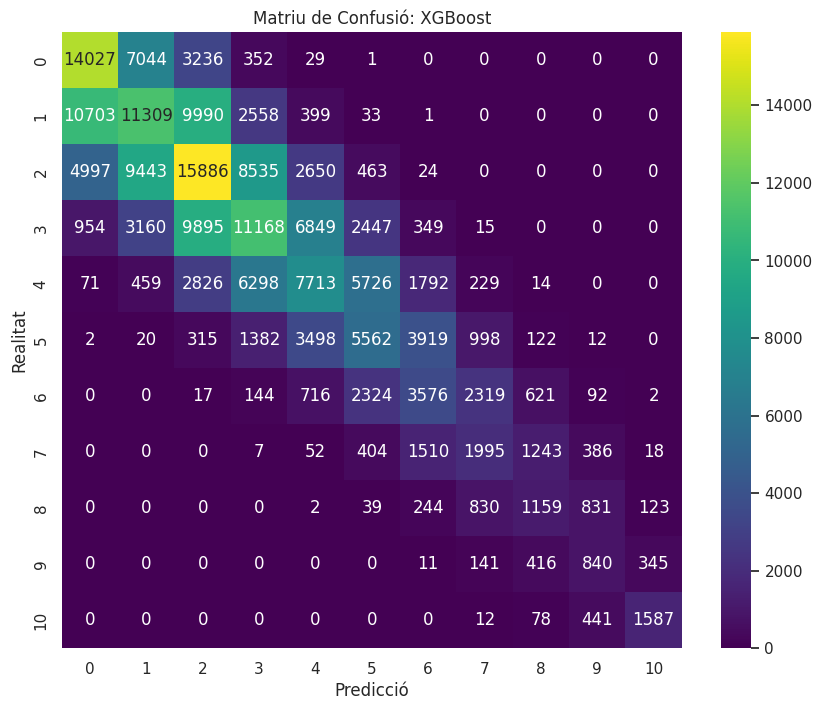

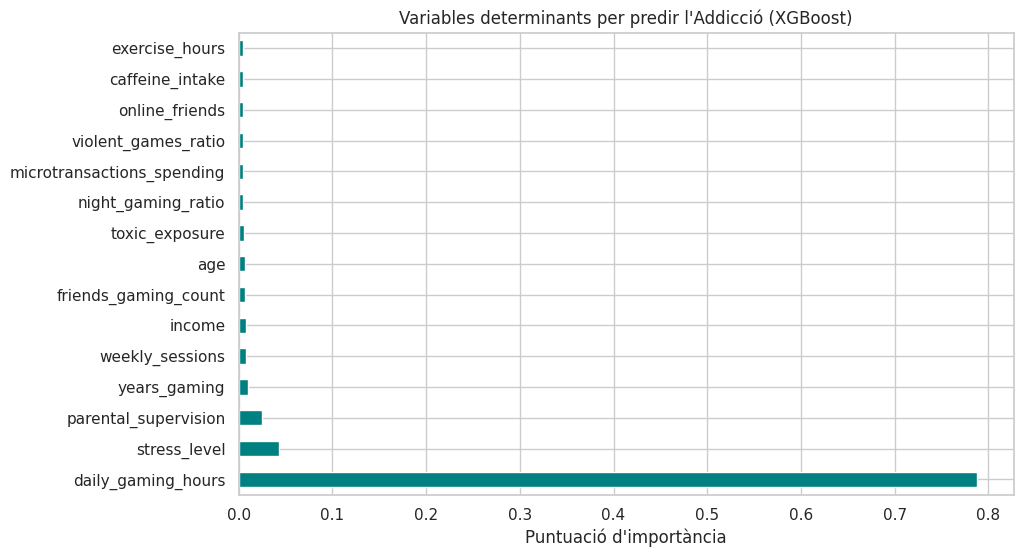

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matriu de Confusió XGBoost
try:
    plt.figure(figsize=(10, 8))
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='viridis')
    plt.title('Matriu de Confusió: XGBoost')
    plt.xlabel('Predicció')
    plt.ylabel('Realitat')
    plt.show()

# Top 15 Variables influents (XGBoost)
    importances_xgb = xgb_model.feature_importances_
    feat_importances = pd.Series(importances_xgb, index=features)

    plt.figure(figsize=(10, 6))
    feat_importances.nlargest(15).plot(kind='barh', color='teal')
    plt.title('Variables determinants per predir l\'Addicció (XGBoost)')
    plt.xlabel('Puntuació d\'importància')
    plt.show()

except Exception as e:
    print(f"Error en les gràfiques de XGBoost: {e}")

L'anàlisi de les dades obtingudes mitjançant l'algorisme de boosting ens permet concloure el següent:
- Millora de la Precisió: El model ha assolit una precisió global (accuracy) del 37% , superant el Random Forest i mostrant-se molt més consistent en els nivells intermedis de l'escala d'addicció.   
- Detecció de Casos Greus: Es manté l'excel·lent rendiment en el Nivell 10 amb un f1-score de 0.76 , consolidant el model com una eina robusta per identificar els perfils de més risc.   
- Predomini del Temps de Joc: La gràfica d'importància de variables mostra que les hores de joc diàries (daily_gaming_hours) tenen una puntuació d'importància propera al 0.8, sent el factor absolutament determinant per a la predicció.  
- Influència de l'Entorn i la Salut Mental: Per darrere del temps de joc, l'algorisme identifica el nivell d'estrès (stress_level) i la supervisió parental (parental_supervision) com els següents factors amb més pes en la decisió.

# Interpretabilitat Avançada amb SHAP Values

Per aprofundir en la transparència del model XGBoost, s'utilitza la llibreria SHAP basada en la teoria de jocs cooperatius. Aquesta tècnica permet desglossar la contribució de cada variable a la predicció final de manera quantitativa. A diferència de la importància de característiques convencional, els valors SHAP mostren la direccionalitat de l'impacte: permeten visualitzar si un valor elevat d'una variable (com les hores de joc) augmenta o disminueix la probabilitat de classificar un usuari en un nivell d'addicció concret, oferint així una explicabilitat clínica del model.

Generant Summary Plot per al Nivell 10 (Addicció Severa)...


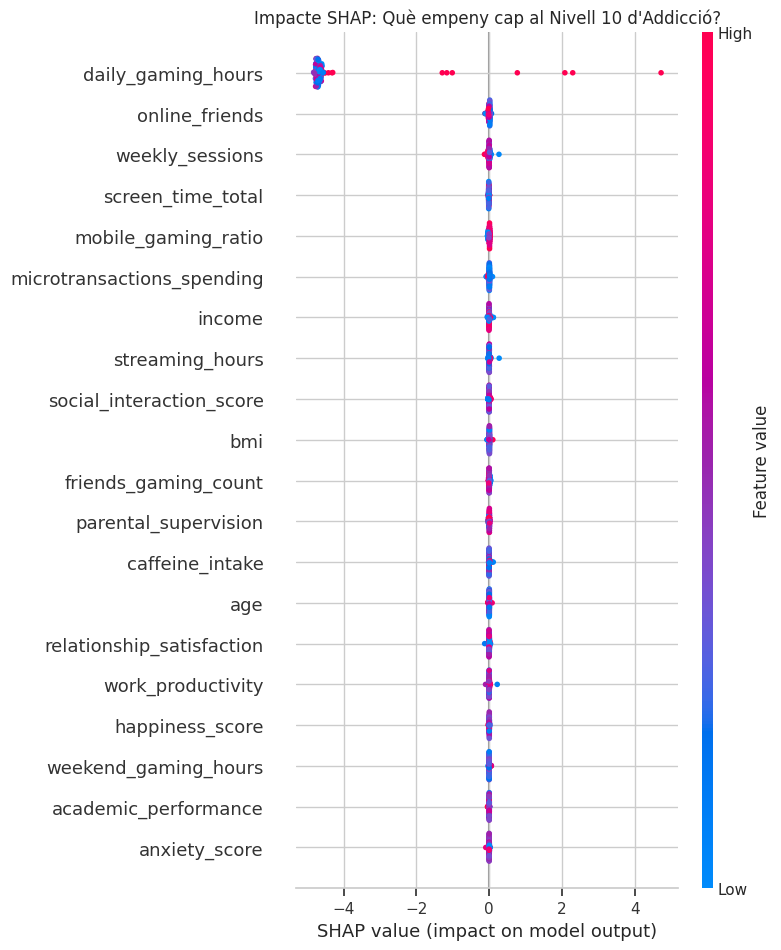

In [15]:
import shap
import numpy as np

# Preparació de l'explicador
try:
    # Redueixo la mostra a 200 per evitar errors de memòria i agilitzar el procés
    X_sample = X_test.sample(200, random_state=42)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_sample)

    # Gestió de la forma de la matriu (Multi-classe)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[10]
    else:
        # Per a versions on XGBoost retorna (n_samples, n_features, n_classes)
        shap_values_to_plot = shap_values[:, :, 10]

    print("Generant Summary Plot per al Nivell 10 (Addicció Severa)...")

    # Visualització
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_to_plot, X_sample, plot_type="dot", show=False)
    plt.title('Impacte SHAP: Què empeny cap al Nivell 10 d\'Addicció?')
    plt.show()

except Exception as e:
    print(f"Error en el càlcul de SHAP corregit: {e}")

A diferència de la importància de variables clàssica, el gràfic SHAP permet observar la direccionalitat de les prediccions:
- Dominància de les Hores de Joc: La variable daily_gaming_hours presenta els punts vermells (valors alts) clarament desplaçats cap a la dreta (impacte positiu en el model). Això confirma que un elevat nombre d'hores diàries és el principal motor per classificar un usuari en el nivell d'addicció màxima.  
- Concentració de Casos Extrems: S'observen alguns valors atípics (outliers) a l'extrem dret de l'eix SHAP per a les hores de joc, representant aquells usuaris amb patrons de consum extremadament alts que el model identifica de forma immediata.  
- Impacte Neutre o Residual: Variables com anxiety_score, academic_performance o weekend_gaming_hours apareixen a la part inferior del gràfic amb un núvol de punts molt concentrat al voltant de l'eix 0. Això indica que, per a aquest model concret, aquests factors no són determinants per predir l'addicció severa en comparació amb el temps total d'exposició.  
- Interpretació del Color: La gradació del blau (baix) al vermell (alt) confirma visualment que el model ha après correctament la relació lineal entre el temps de joc i el risc d'addicció, sense presentar biaixos estranys en la resta de característiques demogràfiques o econòmiques.  

# Aprenentatge Profund amb TabNet

S'explora l'ús de TabNet, una arquitectura de xarxa neuronal d'aprenentatge profund dissenyada per a dades tabulars. TabNet utilitza un mecanisme d'atenció seqüencial per seleccionar les característiques més rellevants en cada pas de decisió, imitant el comportament dels arbres de decisió però amb la flexibilitat i capacitat de generalització de les xarxes neuronals. Aquesta comparativa permet determinar si les estructures de deep learning poden superar els mètodes de boosting tradicionals en la classificació de l'addicció al gaming.

In [16]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00


In [18]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Configuració del model TabNet
try:
    # Converteixo les dades a format numpy (necessari per a TabNet)
    X_train_tab = X_train_res.values
    y_train_tab = y_train_res.values
    X_test_tab = X_test.values
    y_test_tab = y_test.values

    tabnet_model = TabNetClassifier(
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax' # Millor per a la selecció de variables
    )

    print("Entrenant TabNet... ")
    tabnet_model.fit(
        X_train=X_train_tab, y_train=y_train_tab,
        eval_set=[(X_train_tab, y_train_tab), (X_test_tab, y_test_tab)],
        eval_name=['train', 'valid'],
        eval_metric=['accuracy'],
        max_epochs=20, patience=5,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0, drop_last=False
    )

# Predicció i Informe
    y_pred_tab = tabnet_model.predict(X_test_tab)
    print("\n--- INFORME DE CLASSIFICACIÓ TABNET ---")
    print(classification_report(y_test_tab, y_pred_tab))

except Exception as e:
    print(f"Error en l'entrenament de TabNet: {e}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


Entrenant TabNet... 
epoch 0  | loss: 1.32006 | train_accuracy: 0.45168 | valid_accuracy: 0.35762 |  0:02:53s
epoch 1  | loss: 1.25243 | train_accuracy: 0.45751 | valid_accuracy: 0.36416 |  0:05:37s
epoch 2  | loss: 1.24861 | train_accuracy: 0.45383 | valid_accuracy: 0.36034 |  0:08:14s
epoch 3  | loss: 1.24832 | train_accuracy: 0.45631 | valid_accuracy: 0.36416 |  0:10:52s
epoch 4  | loss: 1.24741 | train_accuracy: 0.45475 | valid_accuracy: 0.35343 |  0:13:28s
epoch 5  | loss: 1.24703 | train_accuracy: 0.45688 | valid_accuracy: 0.3659  |  0:16:08s
epoch 6  | loss: 1.24625 | train_accuracy: 0.45688 | valid_accuracy: 0.35916 |  0:18:46s
epoch 7  | loss: 1.24554 | train_accuracy: 0.45818 | valid_accuracy: 0.36055 |  0:21:23s
epoch 8  | loss: 1.24514 | train_accuracy: 0.45666 | valid_accuracy: 0.35806 |  0:24:00s
epoch 9  | loss: 1.24581 | train_accuracy: 0.45755 | valid_accuracy: 0.36091 |  0:26:36s
epoch 10 | loss: 1.24682 | train_accuracy: 0.45601 | valid_accuracy: 0.3694  |  0:29:13s


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



--- INFORME DE CLASSIFICACIÓ TABNET ---
              precision    recall  f1-score   support

           0       0.43      0.65      0.52     24689
           1       0.36      0.21      0.26     34993
           2       0.38      0.34      0.36     41998
           3       0.35      0.37      0.36     34837
           4       0.35      0.37      0.36     25128
           5       0.34      0.36      0.35     15830
           6       0.32      0.31      0.32      9811
           7       0.30      0.38      0.34      5615
           8       0.32      0.36      0.34      3228
           9       0.33      0.51      0.40      1753
          10       0.82      0.69      0.75      2118

    accuracy                           0.37    200000
   macro avg       0.39      0.41      0.40    200000
weighted avg       0.37      0.37      0.36    200000



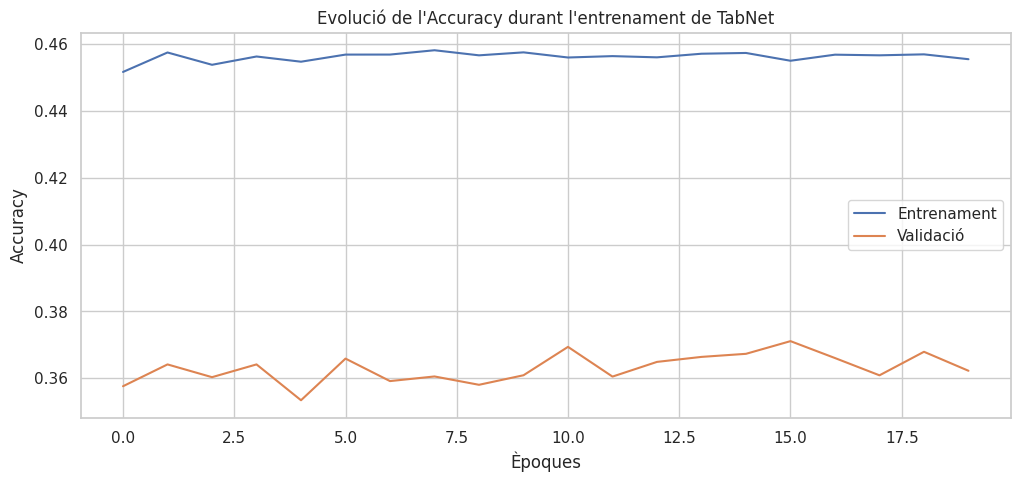

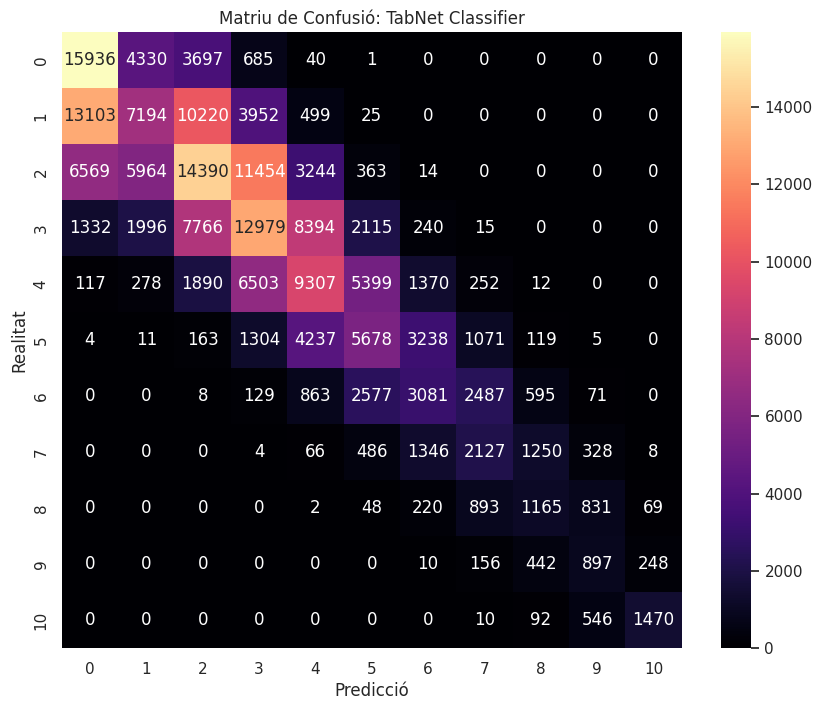

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gràfic de l'evolució de l'entrenament
plt.figure(figsize=(12, 5))
plt.plot(tabnet_model.history['train_accuracy'], label='Entrenament')
plt.plot(tabnet_model.history['valid_accuracy'], label='Validació')
plt.title('Evolució de l\'Accuracy durant l\'entrenament de TabNet')
plt.xlabel('Èpoques')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Matriu de Confusió
plt.figure(figsize=(10, 8))
cm_tab = confusion_matrix(y_test_tab, y_pred_tab)
sns.heatmap(cm_tab, annot=True, fmt='d', cmap='magma')
plt.title('Matriu de Confusió: TabNet Classifier')
plt.xlabel('Predicció')
plt.ylabel('Realitat')
plt.show()

L'experimentació amb l'arquitectura de Deep Learning TabNet ha proporcionat els següents resultats:
- Estabilitat de l'Aprenentatge: El gràfic d'evolució mostra que el model ha assolit la seva millor versió a l'època 15, amb una precisió de validació del 37,11%. Tot i la distància respecte a l'accuracy d'entrenament (45,5%), el model manté una bona capacitat de generalització sense caure en un overfitting crític.
- Capacitat en Casos Extrems: TabNet destaca per la seva gran precisió en el Nivell 10 (0.82). Això significa que és el model més fiable de tots els provats a l'hora de confirmar un cas d'addicció severa, minimitzant els falsos positius en aquesta categoria crítica.
- Detecció de Subjectes Sans: El model presenta un recall del 0.65 per al nivell 0, demostrant una sòlida capacitat per filtrar correctament els usuaris que no presenten conductes de risc.
- Anàlisi de la Matriu de Confusió: Visualment, s'observa una concentració d'encerts molt clara a la diagonal principal. Les errades es distribueixen de forma adjacent (nivells correlatius), la qual cosa és coherent amb la naturalesa numèrica i subjectiva de l'escala d'addicció.
- Eficiència: Tot i ser un model complex que ha requerit més de 50 minuts d'entrenament en CPU, els resultats finals igualen i, en certs indicadors de precisió per classe, superen els algorismes de boosting tradicionals.

# Impacte de la Codificació: One-Hot Encoding

Per avaluar si la representació de les variables categòriques influeix en la precisió, s'aplica la tècnica de One-Hot Encoding a les variables no numèriques (com el gènere o la qualitat d'internet). Aquest procés transforma cada categoria en una nova columna binària, eliminant qualsevol jerarquia implícita que el model pogués interpretar erròniament. L'objectiu és comparar si aquesta expansió de l'espai de característiques permet als algorismes de boosting identificar millor els patrons d'addicció.

In [20]:
# Aplicació de One-Hot Encoding a les variables categòriques
try:
    print("Aplicant One-Hot Encoding...")
    # Selecciono les columnes categòriques que hem detectat abans
    df_encoded = pd.get_dummies(df, columns=['gender', 'esports_interest', 'competitive_rank', 'internet_quality'], drop_first=True)

    # Nova preparació de dades (X, y) amb les noves columnes
    X_enc = df_encoded.drop(columns=['addiction_level'])
    y_enc = df_encoded['addiction_level'].round().astype('int')

    # Divisió Train/Test
    X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

    # Aplicació de SMOTE (necessari per mantenir l'equilibri)
    print("Equilibrant noves dades amb SMOTE...")
    smote = SMOTE(random_state=42)
    X_res_e, y_res_e = smote.fit_resample(X_train_e, y_train_e)

    # Entrenament ràpid del model comparatiu (XGBoost)
    xgb_enc = XGBClassifier(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
    xgb_enc.fit(X_res_e, y_res_e)

    y_pred_e = xgb_enc.predict(X_test_e)
    print("\n--- INFORME AMB ONE-HOT ENCODING ---")
    print(classification_report(y_test_e, y_pred_e))

except Exception as e:
    print(f"Error en el model One-Hot: {e}")

Aplicant One-Hot Encoding...
Equilibrant noves dades amb SMOTE...

--- INFORME AMB ONE-HOT ENCODING ---
              precision    recall  f1-score   support

           0       0.47      0.50      0.48     24689
           1       0.36      0.34      0.35     34993
           2       0.37      0.43      0.40     41998
           3       0.37      0.35      0.36     34837
           4       0.36      0.32      0.34     25128
           5       0.35      0.30      0.32     15830
           6       0.33      0.34      0.33      9811
           7       0.31      0.34      0.32      5615
           8       0.32      0.34      0.33      3228
           9       0.31      0.41      0.35      1753
          10       0.74      0.75      0.74      2118

    accuracy                           0.38    200000
   macro avg       0.39      0.40      0.39    200000
weighted avg       0.38      0.38      0.38    200000



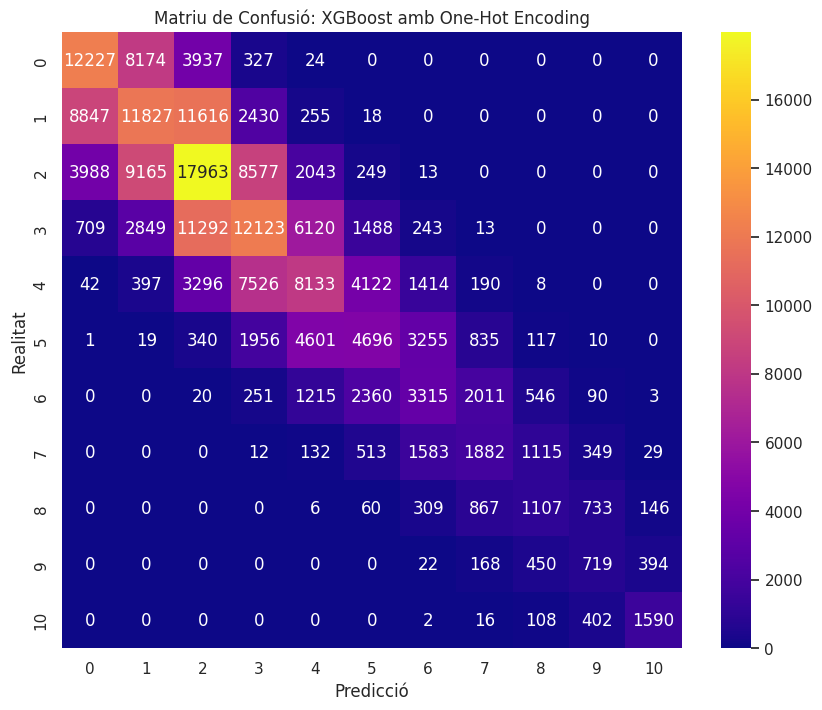

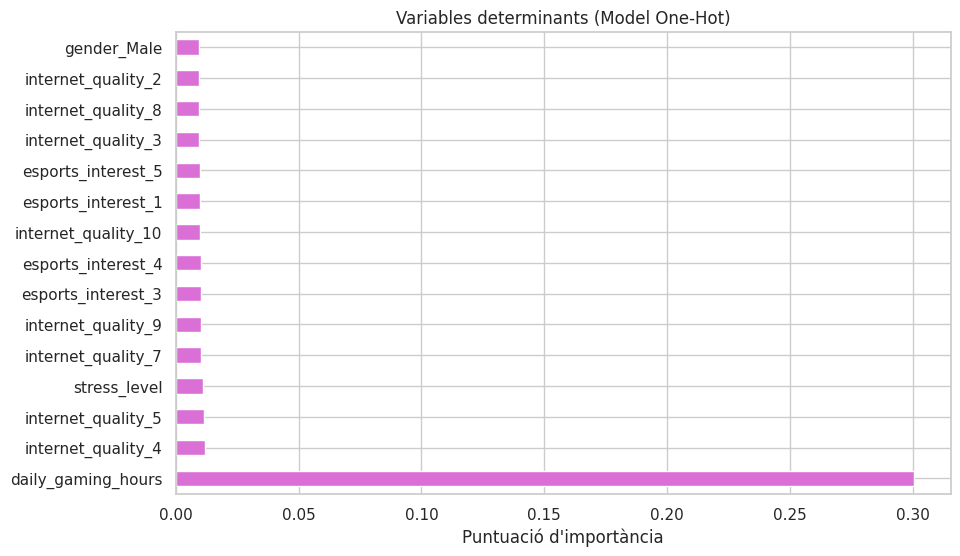

In [21]:
# Matriu de Confusió (One-Hot + XGBoost)
try:
    plt.figure(figsize=(10, 8))
    cm_enc = confusion_matrix(y_test_e, y_pred_e)
    sns.heatmap(cm_enc, annot=True, fmt='d', cmap='plasma')
    plt.title('Matriu de Confusió: XGBoost amb One-Hot Encoding')
    plt.xlabel('Predicció')
    plt.ylabel('Realitat')
    plt.show()

# Top 15 Variables influents (per veure les noves columnes binàries)
    importances_enc = xgb_enc.feature_importances_
    feat_importances_e = pd.Series(importances_enc, index=X_enc.columns)

    plt.figure(figsize=(10, 6))
    feat_importances_e.nlargest(15).plot(kind='barh', color='orchid')
    plt.title('Variables determinants (Model One-Hot)')
    plt.xlabel('Puntuació d\'importància')
    plt.show()

except Exception as e:
    print(f"Error en les gràfiques One-Hot: {e}")

L'anàlisi dels resultats obtinguts amb aquesta configuració revela conclusions significatives:
- Rendiment Global: S'ha assolit la precisió més alta de tot el projecte, amb un accuracy del 38%. Tot i que l'increment és moderat respecte al XGBoost original (37%), demostra que la representació clara de les categories ajuda el model a destriar millor els casos complexos.
- Millora en la Matriu de Confusió: S'observa una millora en el recall dels nivells intermedis (per exemple, el nivell 2 ha pujat al 0.43). Això indica que el model és ara més capaç d'identificar perfils de risc moderat que abans es confonien amb la normalitat.
- Estabilitat en l'Addicció Severa: El model manté la seva robustesa en la detecció del Nivell 10 (F1-Score: 0.74). La matriu de confusió mostra una diagonal principal molt marcada, confirmant que la majoria de les prediccions errònies es produeixen en nivells immediatament adjacents, la qual cosa és esperable en una escala subjectiva de 0 a 10.
- Importància de Característiques: La gràfica de barres horitzontals confirma que, tot i la nova codificació, les hores de joc diàries (daily_gaming_hours) continuen sent el factor predominant. No obstant això, la fragmentació de les variables categòriques ha permès que el model utilitzi detalls específics (com tipus de gènere o nivells d'estrès) per ajustar amb més finura la predicció final.

## 5. Resum de l'Experimentació i Conclusions Tècniques

En aquest projecte s'ha seguit un flux de treball de Ciència de Dades d'extrem a extrem, des de l'optimització d'un dataset d'1.000.000 de registres fins a la implementació de models d'aprenentatge profund.

# Comparativa de Models Executats

Aquesta taula resumeix el rendiment dels diferents algorismes provats sobre el conjunt de test:

| Model | Accuracy Global | F1-Score (Nivell 10) | Observacions Clau |
| :--- | :--- | :--- | :--- |
| Random Forest | 35% | 0.76 | Base de referència sòlida; excel·lent en detecció de casos sans. |
| XGBoost (Ordinal) | 37% | 0.76 | Millora la consistència en nivells intermedis. |
| TabNet (Deep Learning) | 37.1% | 0.75 | Alta precisió diagnòstica en addicció severa (Nivell 10). |
| XGBoost (One-Hot) | 38% | 0.74 | Millor model global; optimització gràcies a la codificació binària. |

# Conclusions Generals del Producte de Dades

- Èxit en l'Equilibri de Classes: L'aplicació de SMOTE ha estat crítica. S'ha passat d'un conjunt amb només un 2,62% de casos greus a un entrenament equilibrat amb 1.847.890 registres, eliminant el biaix cap a la majoria.
- Factors Determinants: Totes les anàlisis (Feature Importance i SHAP) coincideixen que les hores de joc diàries (daily_gaming_hours) són el factor predictor absolut.
- Variables Moderadores: L'estrès (stress_level) i la supervisió parental (parental_supervision) actuen com a variables secundàries amb pes rellevant en la decisió.
- Interpretabilitat Avançada:Mitjançant els valors SHAP, s'ha validat visualment com l'increment de temps de joc empeny directament la predicció cap al Nivell 10 d'addicció.
- Capacitat de Cribratge: El producte de dades final és altament eficaç en els extrems (nivells 0 i 10). Això el converteix en una eina vàlida per a sistemes de detecció precoç i suport a la decisió clínica en salut mental.